<a href="https://colab.research.google.com/github/fernandodeeke/epidemy/blob/main/sir_discrete_basic_vs_exponential.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

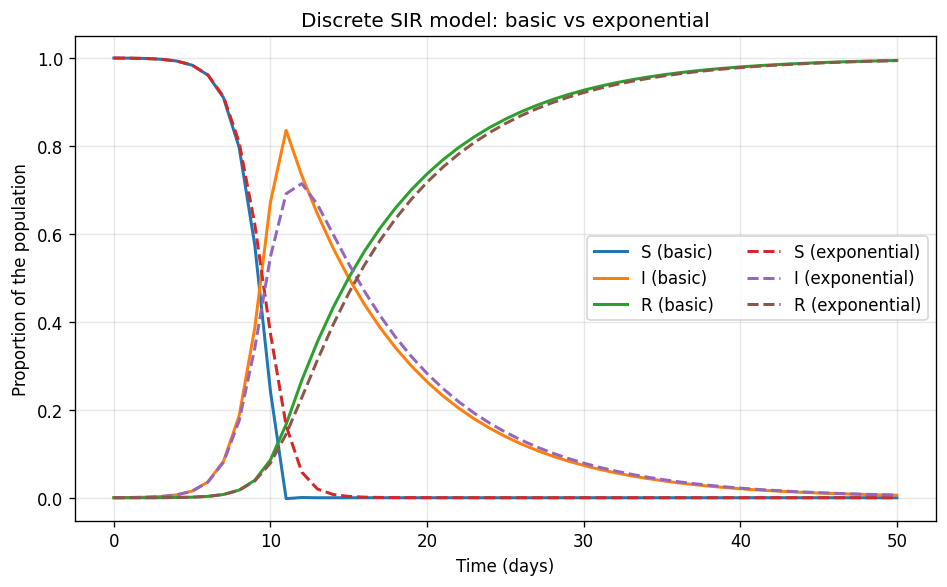

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Model parameters
beta = 1.5          # Infectiousness (transmission rate)
gamma = 0.12        # Recovery rate
T = 50              # Simulation length (days)
S0 = 4999           # Initial number of susceptibles
I0 = 1              # Initial number of infected
R0 = 0.0            # Initial number of recovered

# Initialize state variables (basic discrete model)
steps = T + 1  # Includes the initial point
S = np.zeros(steps)
I = np.zeros(steps)
R = np.zeros(steps)
time = np.linspace(0, T, steps)  # Time vector

# Initial state (basic model)
S[0] = S0
I[0] = I0
R[0] = R0
N = S0 + I0 + R0

# Iteration (basic model)
for t in range(steps - 1):
    S[t + 1] = S[t] - beta * S[t] * I[t] / N
    I[t + 1] = I[t] + (beta * S[t] * I[t] / N - gamma * I[t])
    R[t + 1] = R[t] + gamma * I[t]

# Exponential discrete model
S_exp = np.zeros(steps)
I_exp = np.zeros(steps)
R_exp = np.zeros(steps)

# Initial state (exponential model)
S_exp[0] = S0
I_exp[0] = I0
R_exp[0] = R0

# Iteration (exponential model)
for t in range(steps - 1):
    S_exp[t + 1] = np.exp(-beta * I_exp[t] / N) * S_exp[t]
    new_infections = S_exp[t] - S_exp[t + 1]
    I_exp[t + 1] = I_exp[t] + new_infections - gamma * I_exp[t]
    R_exp[t + 1] = R_exp[t] + gamma * I_exp[t]

# Plot
plt.figure(figsize=(8, 5), dpi=120)
plt.plot(time, S / N,       label="S (basic)", lw=1.8)
plt.plot(time, I / N,       label="I (basic)", lw=1.8)
plt.plot(time, R / N,       label="R (basic)", lw=1.8)
plt.plot(time, S_exp / N,   label="S (exponential)", lw=1.8, ls="--")
plt.plot(time, I_exp / N,   label="I (exponential)", lw=1.8, ls="--")
plt.plot(time, R_exp / N,   label="R (exponential)", lw=1.8, ls="--")
plt.title("Discrete SIR model: basic vs exponential")
plt.xlabel("Time (days)")
plt.ylabel("Proportion of the population")
plt.legend(ncol=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("sir_compare_all.png", dpi=300)
plt.show()